In [4]:
import matplotlib.pyplot as plt
import pandas as pd

base_abc = pd.read_csv("Base_ABC_Flor-Colheita.csv")

In [5]:
#variaveis utilizadas

variaveis = [ 
    "UF",
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Altitude Média [classe]",
    "Semeadura [data]",
    "Colheita [data]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Genótipos",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "NH.UR > 90 [sum]",
    "Ciclo Semeadura-Colheita [dias]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Inseticida Planejado [aplicações]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Colheita [decendio]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "Semeadura [decendio]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
]

base_abc_X  = base_abc[variaveis].copy()
base_abc_Y = base_abc["Produtividade Realizada [kg/ha]"]

#transformando as datas
base_abc_X["Semeadura [data]"] = pd.to_datetime(base_abc_X["Semeadura [data]"], errors='coerce')
base_abc_X["Colheita [data]"] = pd.to_datetime(base_abc_X["Colheita [data]"], errors='coerce')

for col in ["Semeadura [data]", "Colheita [data]"]:
    base_abc_X[f"{col}_ano"] = base_abc_X[col].dt.year
    base_abc_X[f"{col}_mes"] = base_abc_X[col].dt.month
    base_abc_X[f"{col}_dia"] = base_abc_X[col].dt.day


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

variaveis_categoricas = [
    "UF",
    "Altitude Média [classe]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Genótipos"
]

variaveis_numericas = [
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "NH.UR > 90 [sum]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
    "Semeadura [data]_ano",
    "Semeadura [data]_mes",
    "Semeadura [data]_dia",
    "Colheita [data]_ano",
    "Colheita [data]_mes",
    "Colheita [data]_dia",
    "Colheita [decendio]",
    "Semeadura [decendio]",
    "Inseticida Planejado [aplicações]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "Ciclo Semeadura-Colheita [dias]",
]

#transforma valores que estavam sendo interpretados como str em valores numericos
for col in variaveis_numericas:
    if base_abc_X[col].dtype == "object":
        base_abc_X[col] = (
            base_abc_X[col].str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

pipeline_numericas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # preenche valores vazios com a média
])

pipeline_categoricas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # preenche valores vazios com o valor mais comum
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  
])

preprocessador = ColumnTransformer(transformers=[
    ('num', pipeline_numericas, variaveis_numericas),
    ('cat', pipeline_categoricas, variaveis_categoricas)
])

In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

mlp = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', MLPRegressor())
])

knn = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('regressor', KNeighborsRegressor(n_neighbors = 3))
])

decision_tree = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', DecisionTreeRegressor())
])

random_forest = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', RandomForestRegressor())
])

In [8]:
mlp.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [9]:
knn.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [10]:
decision_tree.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [11]:
random_forest.fit(base_abc_X, base_abc_Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [12]:
decision_tree_importance = decision_tree.named_steps['regressor'].feature_importances_ #dessa forma pois é um pipeline

In [13]:
import numpy as np

# Pegar nomes das features após preprocessador
dt_onehot = decision_tree.named_steps['preprocessamento'].named_transformers_['cat'].named_steps['onehot']
dt_categorical_expanded_names = dt_onehot.get_feature_names_out(variaveis_categoricas)

dt_feature_names = np.concatenate([variaveis_numericas, dt_categorical_expanded_names])

dt_df_importances = pd.DataFrame({
    'feature_expanded': dt_feature_names,
    'importance': decision_tree_importance
})

# Pega o nome da variável antes do _ e agrupa
# Ex: Solo Grupo_A -> Solo Grupo
dt_df_importances['feature_original'] = dt_df_importances['feature_expanded'].apply(
    lambda x: x.split('_')[0] if x.split('_')[0] in variaveis_categoricas else x
)

dt_df_grouped = dt_df_importances.groupby('feature_original')['importance'].sum()
dt_df_grouped = dt_df_grouped.sort_values(ascending=False)

print(dt_df_grouped)

feature_original
Talhão Latitude [grau decimal]            0.214815
Talhão Longitude [grau decimal]           0.050904
Genótipos                                 0.045983
Talhão                                    0.045781
Altitude Mínima [m]                       0.035373
ND.TMAX > 30 [sum]                        0.031931
Precipitação [soma]                       0.027520
Fungicida Planejado [aplicações]          0.026796
Colheita [data]_dia                       0.026082
Temperatura Ar Mínima [soma]              0.024426
Fotoperiodo [soma]                        0.023249
NH.UR > 90 [sum]                          0.022836
ND.PREC = 0.0 [sum]                       0.021623
ND.PREC > 0.2 [sum]                       0.020641
NH.RAD > 800 [sum]                        0.020273
Amplitude Térmica [soma]                  0.019319
NH.UR < 60 [sum]                          0.019061
ND.RAD < 10 [sum]                         0.018549
Herbicida Planejado [aplicações]          0.018323
Altitude Máxim

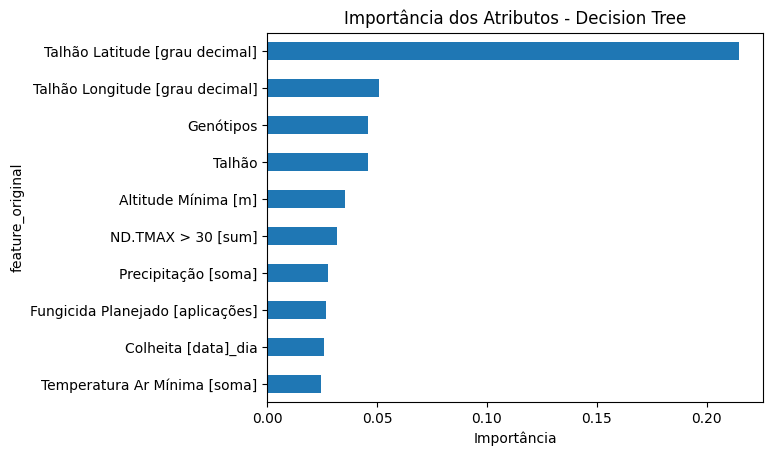

In [14]:
dt_df_grouped.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - Decision Tree")
plt.xlabel("Importância")
plt.show()

In [15]:
random_forest_importance = random_forest.named_steps['regressor'].feature_importances_

In [16]:
rf_onehot = random_forest.named_steps['preprocessamento'].named_transformers_['cat'].named_steps['onehot']
rf_categorical_expanded_names = rf_onehot.get_feature_names_out(variaveis_categoricas)

rf_feature_names = np.concatenate([variaveis_numericas, rf_categorical_expanded_names])

rf_df_importances = pd.DataFrame({
    'feature_expanded': rf_feature_names,
    'importance': random_forest_importance
})

rf_df_importances['feature_original'] = rf_df_importances['feature_expanded'].apply(
    lambda x: x.split('_')[0] if x.split('_')[0] in variaveis_categoricas else x
)

rf_df_grouped = rf_df_importances.groupby('feature_original')['importance'].sum()
rf_df_grouped = rf_df_grouped.sort_values(ascending=False)

print(rf_df_grouped)

feature_original
Talhão Latitude [grau decimal]            0.198790
Talhão Longitude [grau decimal]           0.072365
Talhão                                    0.064268
Genótipos                                 0.060305
Altitude Mínima [m]                       0.036817
Precipitação [soma]                       0.025100
Colheita [data]_dia                       0.023446
ND.TMAX > 30 [sum]                        0.021105
Fungicida Planejado [aplicações]          0.020662
NH.UR < 60 [sum]                          0.020203
Herbicida Planejado [aplicações]          0.019745
Altitude Média [m]                        0.018790
NH.RAD > 1000 [sum]                       0.018429
Semeadura [data]_dia                      0.018084
Altitude Máxima [m]                       0.018071
ND.RAD < 10 [sum]                         0.016735
Genótipos Propósito                       0.016502
NH.UR > 90 [sum]                          0.016105
Amplitude Térmica [soma]                  0.016069
Inseticida Pla

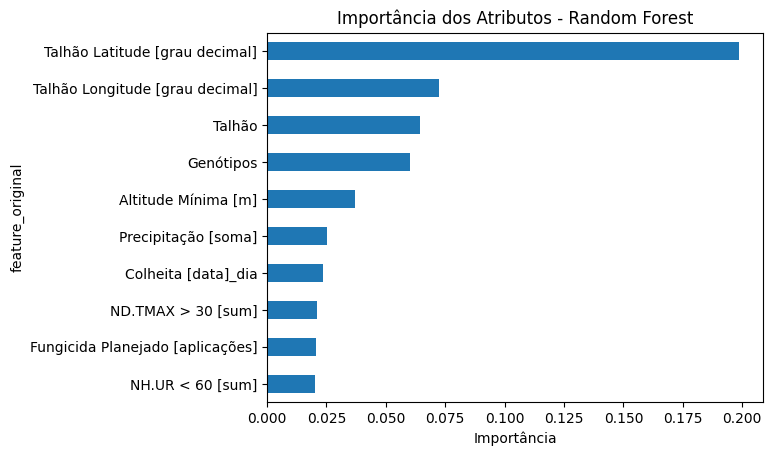

In [17]:
rf_df_grouped.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - Random Forest")
plt.xlabel("Importância")
plt.show()

In [18]:
from sklearn.inspection import permutation_importance

mlp_importance = permutation_importance(mlp, base_abc_X, base_abc_Y, scoring="neg_mean_squared_error")

In [19]:
knn_importance = permutation_importance(knn, base_abc_X, base_abc_Y, scoring="neg_mean_squared_error")

In [20]:
print(mlp_importance.importances_mean)

[ 1.40224211e-03  3.98645909e-03  3.83926952e-03  3.43319980e-02
  0.00000000e+00  0.00000000e+00  4.51689344e-03  0.00000000e+00
  7.07547249e-04  1.06696498e+00  4.79928955e-02  2.38450981e-03
  3.23164299e-05  1.50246535e-04  1.51857751e-04  1.41229887e-01
  3.40193567e-05  9.57480476e-04  2.40358815e-03  3.29094844e-04
  1.25413557e-03  1.04301671e-04  1.06885233e-04  6.03511609e-05
  9.50093363e-04  1.29758298e-04  1.08399002e-03  1.06464819e-03
 -2.36526401e-06  2.68646979e-04  2.24368116e-03  1.02311012e-04
  1.55445904e-06  4.19419991e-04  1.51728258e-04  7.57774482e-05
  2.02894177e-03  1.89425584e-04  2.19411098e-04  4.88806719e-04
  2.07627307e-04  1.97804586e-04 -1.56128821e-05  4.27159176e-06
  7.46714128e-04  8.89116592e-05  8.09644386e-04  1.55685204e-04
  2.13481259e-04  3.14794375e-06  1.11085979e-03  6.93130084e-04
  7.56989191e-04  0.00000000e+00  1.14981779e-04  2.31002469e-03
  0.00000000e+00  1.22232658e-03  1.96621615e-03]


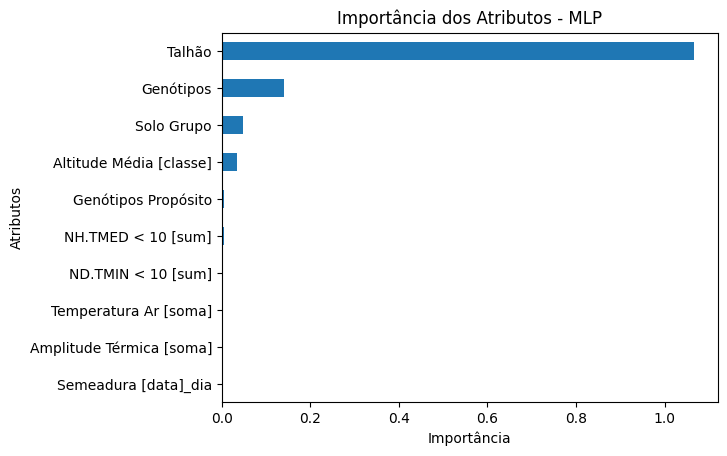

In [21]:
mlp_df_importances = pd.DataFrame({
    "feature": base_abc_X.columns,
    "importance": mlp_importance.importances_mean
})

mlp_top_10 = (
    mlp_df_importances
    .sort_values(by="importance", ascending=False)
    .head(10)
)

mlp_top_10.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - MLP")
plt.xlabel("Importância")
plt.ylabel("Atributos")
plt.show()

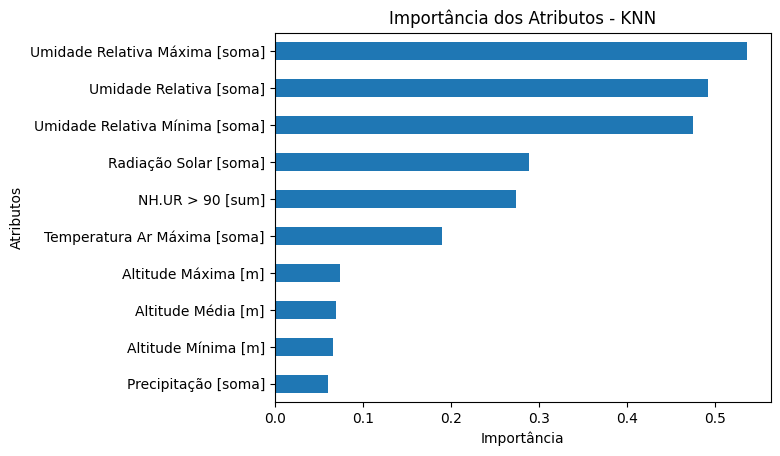

In [22]:
knn_df_importances = pd.DataFrame({
    "feature": base_abc_X.columns,
    "importance": knn_importance.importances_mean
})

knn_top_10 = (
    knn_df_importances
    .sort_values(by="importance", ascending=False)
    .head(10)
)

knn_top_10.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - KNN")
plt.xlabel("Importância")
plt.ylabel("Atributos")
plt.show()